In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck18')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.catalog.accumulate import *
from compact.catalog.bin import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *
from compact.model import *
from compact.predictions import *
import compact.config as config

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import os
import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

from scipy.optimize import curve_fit

In [2]:
# how long to initialize and obtain model prediction for \xi_0, \xi_4?
from compact.config import Config

cfg = Config() 

csm = CompactStreamingModel(0.5, cfg) 

In [4]:
gli = GetLPTInputs(0.5)

In [45]:
np.concatenate( (np.array([1, 0.5]), np.zeros(7)) )

array([1. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ])

TypeError: 'NoneType' object is not subscriptable

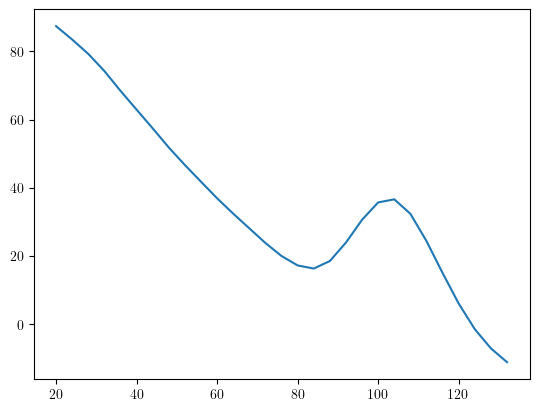

In [5]:
test = gli.xi_real(config.r, [1, 0.5, 0, 0, 0, 0, 0, 0, 0])

plt.plot(config.r, config.r**2*test)
plt.plot(config.r, config.r**2*csm._lpt[0])

In [ ]:
xir_first = gli.xi_real(config.r, [1, 0.5, 0, 0, 0, 0, 0, 0, 0])
print(np.allclose(xir_first, 0), xir_first[:5])   # should be nonzero, real values

_ = gli.pwv_mean(config.r, [1, 0.5, 0, 0, 0, 0, 0, 0, 0])                  # second cumulant-computing call
print(np.allclose(xir_first, 0), xir_first[:5])    # if this NOW prints True/near-zero,
                                                     # xir_first was a view, not a xxcopy

False [0.21850244 0.1449262  0.10110066 0.07249495 0.05279991]
False [0.21850244 0.1449262  0.10110066 0.07249495 0.05279991]


csm.z: 0.5
theta used for csm.predict(): [0.5, 0.5, 0.6777, 0.02214, 0.11891, 2.2e-09]
cosmo built from theta: (0.11891, 0.6777, 0.02214, 2.2e-09)


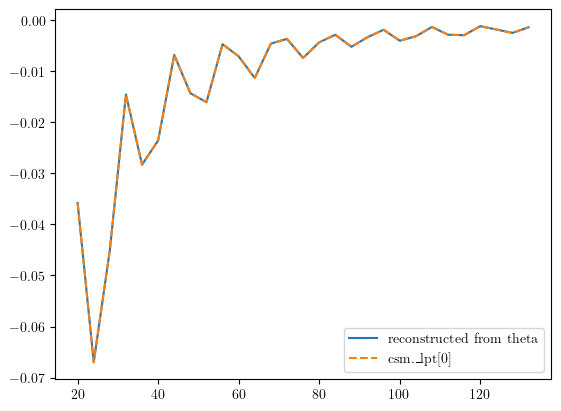

In [50]:
theta = [0.5, 0.5, 0.6777, 0.02214, 0.11891, 2.2e-9]
print("csm.z:", csm.z)
print("theta used for csm.predict():", theta)   # whatever you actually passed

b1, b2, ombh2, omch2, h, As = theta
cosmo_from_theta = (h, ombh2, omch2, As)
print("cosmo built from theta:", cosmo_from_theta)

# now reconstruct gli exactly as _lpt_inputs would, and compare directly
gli_check = GetLPTInputs(csm.z, cosmo_from_theta, np.concatenate(([b1, b2], np.zeros(7))))
xir_check = gli_check.xi_real(config.r, np.concatenate(([b1, b2], np.zeros(7))))

plt.plot(config.r, config.r**2 * xir_check, label='reconstructed from theta')
plt.plot(config.r, config.r**2 * csm._lpt[0], label='csm._lpt[0]', ls='--')
plt.legend()

In [3]:
theta = [0.65, 0.1, 0.02214, 0.11891, 0.6777, 2.2e-09]   # b1, b2, ombh2, omch2, h, As
mono, quad, hexa = csm.predict(theta, ells=(0, 2, 4))

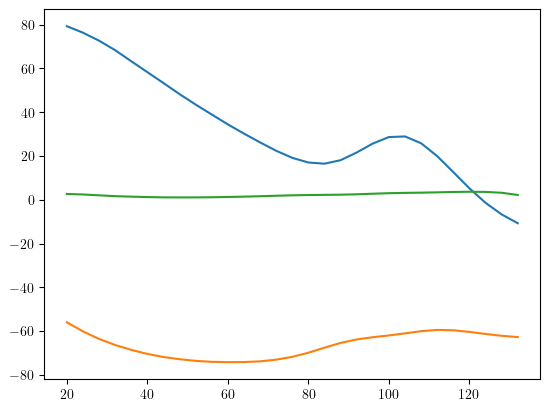

In [6]:
plt.plot(config.r, config.r**2*mono)
plt.plot(config.r, config.r**2*quad)
plt.plot(config.r, config.r**2*hexa)

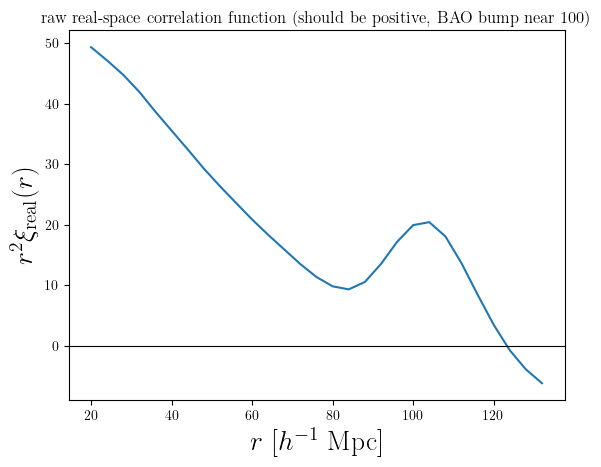

PDF normalization check (should all be ~1.0):
  r_p=  30.0, r_los=   0.0  ->  integral = 0.9995
  r_p=  30.0, r_los=  30.0  ->  integral = 0.9991
  r_p=  72.5, r_los=  20.0  ->  integral = 0.9991
  r_p= 100.0, r_los= -50.0  ->  integral = 0.9986

xi_s_mu shape: (29, 120)
xi_s_mu at large s, all mu (should be ~0, not ~-1):
[-0.71762019 -0.71762157 -0.71762433 -0.71762848 -0.71763401 -0.71764092
 -0.71764921 -0.71765888 -0.71766992 -0.71768234 -0.71769613 -0.71771129
 -0.71772782 -0.71774571 -0.71776497 -0.71778558 -0.71780754 -0.71783085
 -0.71785551 -0.7178815  -0.71790883 -0.71793749 -0.71796746 -0.71799875
 -0.71803134 -0.71806523 -0.71810041 -0.71813686 -0.71817459 -0.71821356
 -0.71825379 -0.71829525 -0.71833792 -0.7183818  -0.71842686 -0.7184731
 -0.71852049 -0.71856902 -0.71861865 -0.71866938 -0.71872118 -0.71877403
 -0.71882789 -0.71888274 -0.71893856 -0.7189953  -0.71905295 -0.71911146
 -0.71917081 -0.71923095 -0.71929186 -0.71935348 -0.71941577 -0.71947871
 -0.71954223 -0.7196

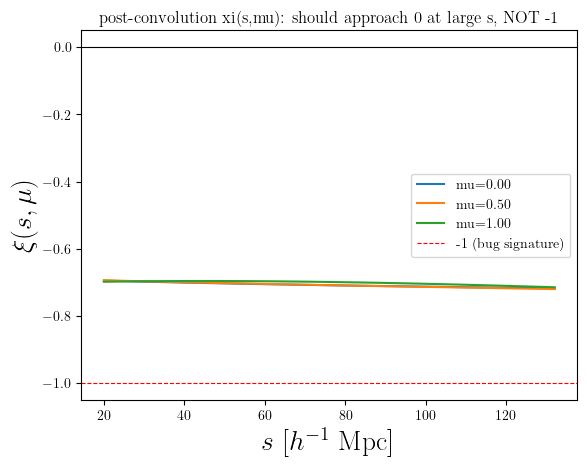

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# --- unpack theta the same way predict() does ---
b1, b2, ombh2, omch2, h, As = [0.5, 0.5, 0.02214, 0.11891, 0.6777, 2.2e-09]
bias  = np.array([b1, b2])
cosmo = (h, ombh2, omch2, As)

lpt = csm._lpt_inputs(cosmo, bias)
pdf = csm._pdf(lpt, cosmo)

# ================================================================
# Check 3: raw xi_real(r) -- should be positive, decaying, BAO bump ~100 Mpc/h
# ================================================================
plt.figure()
plt.plot(config.r, config.r**2*lpt[0])
plt.axhline(0, c='k', lw=0.8)
plt.xlabel(r'$r$ [$h^{-1}$ Mpc]')
plt.ylabel(r'$r^2\xi_{\rm real}(r)$')
plt.title('raw real-space correlation function (should be positive, BAO bump near 100)')
plt.show()

# ================================================================
# Check 2: PDF normalization -- integral over v should be ~1 at fixed (r_p, r_los)
# ================================================================
v_grid = config.vlos
test_points = [(30, 0), (30, 30), (72.5, 20), (100, -50)]  # (r_p, r_los) pairs to spot-check

print("PDF normalization check (should all be ~1.0):")
for r_p, r_los in test_points:
    pv = pdf(v_grid, r_p, r_los)
    norm = simpson(pv, x=v_grid)
    print(f"  r_p={r_p:6.1f}, r_los={r_los:6.1f}  ->  integral = {norm:.4f}")

# ================================================================
# Check 4: what does xi_s_mu (post-1+ convolution, pre-multipole) actually look like?
# Requires calling simps_integrate directly, same args as _multipoles uses.
# ================================================================
from compact.streaming import simps_integrate
from scipy.interpolate import UnivariateSpline

xi_real_spline = UnivariateSpline(config.r, lpt[0], s=0)

xi_s_mu = simps_integrate(
    s_c=config.r, mu_c=config.mu_c,
    twopcf_function=xi_real_spline, los_pdf_function=pdf,
    limit=140, epsilon=0.01, n=100,
)

print(f"\nxi_s_mu shape: {xi_s_mu.shape}")
print(f"xi_s_mu at large s, all mu (should be ~0, not ~-1):")
print(xi_s_mu[-1, :])   # assuming shape is (n_s, n_mu) -- adjust indexing if transposed

plt.figure()
for mu_idx in [0, len(config.mu_c)//2, -1]:
    plt.plot(config.r, xi_s_mu[:, mu_idx], label=f'mu={config.mu_c[mu_idx]:.2f}')
plt.axhline(0, c='k', lw=0.8)
plt.axhline(-1, c='r', ls='--', lw=0.8, label='-1 (bug signature)')
plt.legend()
plt.xlabel(r'$s$ [$h^{-1}$ Mpc]')
plt.ylabel(r'$\xi(s,\mu)$')
plt.title('post-convolution xi(s,mu): should approach 0 at large s, NOT -1')
plt.show()

In [7]:
from scipy.integrate import simpson

# --- conv sanity check ---
print("conv:", lpt[-1])   # = gli.a * gli.H / gli.h

# --- PDF normalization check ---
v_grid = config.vlos
test_points = [(30, 0), (30, 30), (72.5, 20), (100, -50)]

print("\nPDF normalization check (should all be ~1.0):")
for r_p, r_los in test_points:
    pv = pdf(v_grid, r_p, r_los)
    norm = simpson(pv, x=v_grid)
    print(f"  r_p={r_p:6.1f}, r_los={r_los:6.1f}  ->  integral = {norm:.4f}")

conv: 87.76351590167091

PDF normalization check (should all be ~1.0):
  r_p=  30.0, r_los=   0.0  ->  integral = 0.9995
  r_p=  30.0, r_los=  30.0  ->  integral = 0.9991
  r_p=  72.5, r_los=  20.0  ->  integral = 0.9991
  r_p= 100.0, r_los= -50.0  ->  integral = 0.9986
